# Developmental Trajectory: Top 8 Densest Subjects (Month-to-Month RDM Correlation)

Instead of a median age split, this notebook analyzes the **age trajectory** of the **top 8 densest subjects** (by total category count from the trajectory file). For each subject we:

1. Build one RDM per **age month** (e.g. RDM at 6 months, 7 months, …) using only that month's embeddings.
2. **Consecutive-month correlations**: RDM_6 vs RDM_7, RDM_7 vs RDM_8, … (x = age transition, y = correlation).
3. **Youngest vs each later month**: For each subject, correlate the **youngest** month's RDM with **each** later month (e.g. if youngest is 6: 6 vs 7, 6 vs 8, 6 vs 9, …). x = later age, y = correlation with youngest month.
4. Dot size in all plots = number of overlapping categories used for the correlation (except top-50 plots, where dot size is fixed). We also run the same analyses restricted to the **top 50 categories from the long-tailed distribution** (first 50 by proportion detected in `long_tailed_163cats/category_counts_163.csv`).

**Density** is defined as in notebook 10: `n_categories_younger + n_categories_older` from `trajectory_correlations.csv` (developmental_trajectory_rdms).

## Setup and configuration

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

SCRIPT_DIR = Path(".").resolve()
# Normalized embeddings (same as notebook 07)
NORMALIZED_EMBEDDINGS_DIR = Path("/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_grouped_by_age-mo_normalized")
# Trajectory CSV from median-split analysis (used only to get density and top 8)
TRAJECTORY_CSV_DIR = SCRIPT_DIR / "developmental_trajectory_rdms_clip"
TRAJECTORY_CSV = TRAJECTORY_CSV_DIR / "trajectory_correlations.csv"
# Category list and order (same as notebook 07)
CATEGORIES_FILE = SCRIPT_DIR.parent.parent / "data/things_bv_overlap_categories_exclude_zero_precisions.txt"
PREDEFINED_CATEGORY_LIST_PATH = SCRIPT_DIR / "../vss-2026/bv_things_comp_12252025/bv_clip_filtered_zscored_hierarchical_163cats/category_order_reorganized.txt"
EXCLUDED_SUBJECT = "00270001"
MIN_CATEGORIES_PER_MONTH = 8
N_TOP_DENSEST = 8
N_TOP_CATEGORIES = 50   # For top-50 analysis: first 50 from long-tailed distribution
MIN_CATEGORIES_FOR_TOP50 = 5   # Min categories per month when using only top 50
# Top 50 from long-tailed distribution (by proportion detected)
LONGTAIL_COUNTS_CSV = SCRIPT_DIR.parent / "ccn-2025/long_tailed_163cats/category_counts_163.csv"
OUTPUT_DIR = SCRIPT_DIR / "developmental_trajectory_top8_densest"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Embeddings: {NORMALIZED_EMBEDDINGS_DIR}")
print(f"Trajectory CSV: {TRAJECTORY_CSV} (exists: {TRAJECTORY_CSV.exists()})")
print(f"Top {N_TOP_DENSEST} densest subjects; min categories per month: {MIN_CATEGORIES_PER_MONTH}")
print(f"Output: {OUTPUT_DIR}")

Embeddings: /data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_grouped_by_age-mo_normalized
Trajectory CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_rdms_clip/trajectory_correlations.csv (exists: True)
Top 8 densest subjects; min categories per month: 8
Output: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest


## Top 8 densest subjects and load embeddings

In [10]:
# Allowed categories
allowed_categories = None
if CATEGORIES_FILE and CATEGORIES_FILE.exists():
    with open(CATEGORIES_FILE) as f:
        allowed_categories = set(line.strip() for line in f if line.strip())
print(f"Allowed categories: {len(allowed_categories) if allowed_categories else 'all'}")

# Top 8 densest from trajectory_correlations.csv (density = n_younger + n_older)
traj_df = pd.read_csv(TRAJECTORY_CSV)
traj_df["density"] = traj_df["n_categories_younger"] + traj_df["n_categories_older"]
top8_df = traj_df.nlargest(N_TOP_DENSEST, "density")
# Normalize to 8-digit string to match embedding filenames (e.g. 00320001)
top8_subject_ids = [str(x).zfill(8) for x in top8_df["subject_id"].tolist()]
print(f"Top {N_TOP_DENSEST} densest subjects: {top8_subject_ids}")
print(top8_df[["subject_id", "n_categories_younger", "n_categories_older", "density"]].to_string(index=False))

Allowed categories: 163
Top 8 densest subjects: ['00400001', '00370002', '00320001', '00500001', '00400002', '00510002', '00430001', '00560001']
 subject_id  n_categories_younger  n_categories_older  density
     400001                   160                 158      318
     370002                   160                 157      317
     320001                   161                 155      316
     500001                   155                 160      315
     400002                   159                 156      315
     510002                   157                 156      313
     430001                   157                 153      310
     560001                   154                 154      308


In [11]:
def load_embeddings_by_age(embeddings_dir, allowed_categories=None, excluded_subject=None):
    """Load embeddings by subject and age month. Returns subject_age_embeddings[subject_id][age_mo][category] = embedding."""
    subject_age_embeddings = defaultdict(lambda: defaultdict(dict))
    category_folders = [f for f in embeddings_dir.iterdir() if f.is_dir()]
    if allowed_categories:
        category_folders = [f for f in category_folders if f.name in allowed_categories]
    for category_folder in tqdm(category_folders, desc="Loading embeddings"):
        cat = category_folder.name
        for emb_file in category_folder.glob("*.npy"):
            stem = emb_file.stem
            parts = stem.split("_")
            if len(parts) < 2:
                continue
            subject_id, age_str = parts[0], parts[1]
            if excluded_subject and subject_id == excluded_subject:
                continue
            if not age_str.isdigit():
                continue
            age_mo = int(age_str)
            try:
                subject_age_embeddings[subject_id][age_mo][cat] = np.load(emb_file)
            except Exception:
                continue
    return subject_age_embeddings

subject_age_embeddings = load_embeddings_by_age(
    NORMALIZED_EMBEDDINGS_DIR, allowed_categories=allowed_categories, excluded_subject=EXCLUDED_SUBJECT
)
# Restrict to top 8 subjects only
subject_age_embeddings = {sid: subject_age_embeddings[sid] for sid in top8_subject_ids if sid in subject_age_embeddings}
print(f"Loaded {len(subject_age_embeddings)} top-8 subjects; age range per subject varies")

Loading embeddings: 100%|██████████| 163/163 [00:01<00:00, 133.11it/s]

Loaded 8 top-8 subjects; age range per subject varies


In [12]:
# Ordered categories (same as notebook 07)
with open(PREDEFINED_CATEGORY_LIST_PATH) as f:
    ordered_categories = [line.strip() for line in f if line.strip() and not line.strip().startswith("#")]
print(f"Ordered categories: {len(ordered_categories)}")

Ordered categories: 163


## RDM and correlation helpers

In [13]:
def compute_rdm_for_month(month_embeddings_dict, ordered_categories_list, min_cats):
    """Compute RDM for one age month. Returns (rdm, available_categories) or (None, []) if too few categories."""
    available = [c for c in ordered_categories_list if c in month_embeddings_dict]
    if len(available) < min_cats:
        return None, []
    emb_matrix = np.array([month_embeddings_dict[c].flatten() for c in available])
    sim = cosine_similarity(emb_matrix)
    dist = 1 - sim
    np.fill_diagonal(dist, 0)
    dist = (dist + dist.T) / 2
    n = len(ordered_categories_list)
    rdm = np.full((n, n), np.nan)
    idx_map = [ordered_categories_list.index(c) for c in available]
    for i, ii in enumerate(idx_map):
        for j, jj in enumerate(idx_map):
            rdm[ii, jj] = dist[i, j]
    return rdm, available

def compute_rdm_correlation(rdm1, rdm2, ordered_categories_list, available_cats1, available_cats2):
    """Spearman correlation between two RDMs on common categories (upper triangle)."""
    common = [c for c in ordered_categories_list if c in available_cats1 and c in available_cats2]
    if len(common) < 2:
        return np.nan, len(common)
    common_indices = [ordered_categories_list.index(c) for c in common]
    r1 = rdm1[np.ix_(common_indices, common_indices)]
    r2 = rdm2[np.ix_(common_indices, common_indices)]
    mask = np.triu(np.ones_like(r1, dtype=bool), k=1)
    v1 = r1[mask]
    v2 = r2[mask]
    valid = ~(np.isnan(v1) | np.isnan(v2))
    if valid.sum() == 0:
        return np.nan, len(common)
    corr, _ = spearmanr(v1[valid], v2[valid])
    return corr, len(common)

## Per-month RDMs and consecutive-month correlations for top 8

In [14]:
# For each top-8 subject: RDM per age month, then consecutive-month correlations
subject_month_rdms = {}  # subject_id -> {age_mo: (rdm, available_cats)}
subject_trajectory = []  # list of {subject_id, age_from, age_to, age_midpoint, correlation, n_common}

for subject_id in tqdm(subject_age_embeddings, desc="Subject"):
    age_data = subject_age_embeddings[subject_id]
    month_rdms = {}
    for age_mo, cat_embeddings in age_data.items():
        rdm, available = compute_rdm_for_month(
            cat_embeddings, ordered_categories, MIN_CATEGORIES_PER_MONTH
        )
        if rdm is not None:
            month_rdms[age_mo] = (rdm, available)
    subject_month_rdms[subject_id] = month_rdms
    ages_sorted = sorted(month_rdms.keys())
    for i in range(len(ages_sorted) - 1):
        a1, a2 = ages_sorted[i], ages_sorted[i + 1]
        rdm1, cats1 = month_rdms[a1]
        rdm2, cats2 = month_rdms[a2]
        corr, n_common = compute_rdm_correlation(rdm1, rdm2, ordered_categories, cats1, cats2)
        subject_trajectory.append({
            "subject_id": subject_id,
            "age_from": a1,
            "age_to": a2,
            "age_midpoint": (a1 + a2) / 2.0,
            "correlation": corr,
            "n_common_categories": n_common,
        })

trajectory_df = pd.DataFrame(subject_trajectory)
trajectory_df.to_csv(OUTPUT_DIR / "month_to_month_correlations.csv", index=False)
print(f"Consecutive-month correlations: {len(trajectory_df)} rows")
print(trajectory_df.head(10).to_string())

Subject: 100%|██████████| 8/8 [00:00<00:00, 13.07it/s]

Consecutive-month correlations: 100 rows
  subject_id  age_from  age_to  age_midpoint  correlation  n_common_categories
0   00400001        10      11          10.5     0.743639                  114
1   00400001        11      12          11.5     0.771690                  140
2   00400001        12      13          12.5     0.751023                  141
3   00400001        13      14          13.5     0.760252                  143
4   00400001        14      15          14.5     0.690158                  139
5   00400001        15      16          15.5     0.749870                  118
6   00400001        16      17          16.5     0.677459                  117
7   00400001        17      18          17.5     0.687583                  124
8   00400001        18      19          18.5     0.581761                  122
9   00400001        19      20          19.5     0.607420                  123


## Youngest month vs each later month (all categories)

For each subject, take the **youngest age month** with a valid RDM and correlate it with **each** later month (e.g. if youngest is 6: 6 vs 7, 6 vs 8, 6 vs 9, …). So x = age of the later month, y = correlation with the youngest month's RDM. Dot size = number of overlapping categories.

In [15]:
# Youngest-month RDM vs each later month (all categories)
subject_trajectory_youngest = []
for subject_id in subject_month_rdms:
    month_rdms = subject_month_rdms[subject_id]
    if len(month_rdms) < 2:
        continue
    ages_sorted = sorted(month_rdms.keys())
    age_youngest = ages_sorted[0]
    rdm_youngest, cats_youngest = month_rdms[age_youngest]
    for age_other in ages_sorted[1:]:
        rdm_other, cats_other = month_rdms[age_other]
        corr, n_common = compute_rdm_correlation(
            rdm_youngest, rdm_other, ordered_categories, cats_youngest, cats_other
        )
        subject_trajectory_youngest.append({
            "subject_id": subject_id,
            "age_youngest": age_youngest,
            "age_compared": age_other,
            "correlation": corr,
            "n_common_categories": n_common,
        })

trajectory_youngest_df = pd.DataFrame(subject_trajectory_youngest)
trajectory_youngest_df.to_csv(OUTPUT_DIR / "youngest_vs_later_month_correlations.csv", index=False)
print(f"Youngest vs later month: {len(trajectory_youngest_df)} rows")
print(trajectory_youngest_df.head(12).to_string())

Youngest vs later month: 100 rows
   subject_id  age_youngest  age_compared  correlation  n_common_categories
0    00400001            10            11     0.743639                  114
1    00400001            10            12     0.731812                  113
2    00400001            10            13     0.707010                  113
3    00400001            10            14     0.657589                  112
4    00400001            10            15     0.690343                  110
5    00400001            10            16     0.642975                  105
6    00400001            10            17     0.663319                  109
7    00400001            10            18     0.577055                  106
8    00400001            10            19     0.642606                  109
9    00400001            10            20     0.582884                  109
10   00400001            10            21     0.562037                  110
11   00400001            10            22     0.543038

## Stats: Does correlation change with age?

We test whether RDM correlation systematically changes with development/age in two ways:

1. **Consecutive-month**: Does the correlation between adjacent months (e.g. 6 vs 7, 7 vs 8) change as children get older? (Spearman: age_midpoint vs correlation; within-subject slope; mixed-effects model with random intercept by subject.)
2. **Youngest vs later**: Does correlation with the youngest month decrease as the compared age increases? (Spearman: age_compared vs correlation; within-subject slope; mixed-effects model with random intercept by subject.)

In [16]:
from scipy.stats import spearmanr, linregress, ttest_1samp
try:
    import statsmodels.api as sm
    from statsmodels.regression.mixed_linear_model import MixedLM
    HAS_STATSMODELS = True
except ModuleNotFoundError:
    HAS_STATSMODELS = False

# --- 1. Consecutive-month: does correlation change with age? ---
rho_consec, p_consec = spearmanr(trajectory_df["age_midpoint"], trajectory_df["correlation"])
print("Consecutive-month (all categories)")
print("  Spearman(age_midpoint, correlation): rho = {:.4f}, p = {:.4f}".format(rho_consec, p_consec))

# Within-subject slope: correlation ~ age_midpoint for each subject
slopes_consec = []
for sid in trajectory_df["subject_id"].unique():
    sub = trajectory_df[trajectory_df["subject_id"] == sid].sort_values("age_midpoint")
    if len(sub) < 2:
        continue
    res = linregress(sub["age_midpoint"], sub["correlation"])
    slopes_consec.append(res.slope)
slopes_consec = np.array(slopes_consec)
if len(slopes_consec) > 0:
    t_consec, p_t_consec = ttest_1samp(slopes_consec, 0)
    print("  Within-subject slope (correlation ~ age_midpoint): mean slope = {:.5f}, 1-sample t vs 0: t = {:.3f}, p = {:.4f}".format(
        slopes_consec.mean(), t_consec, p_t_consec))

# Mixed-effects: correlation ~ age_midpoint + (1 | subject_id)
if HAS_STATSMODELS:
    X_consec = sm.add_constant(trajectory_df[["age_midpoint"]])
    model_consec = MixedLM(trajectory_df["correlation"], X_consec, trajectory_df["subject_id"]).fit(method="lbfgs")
    print("  Mixed-effects (correlation ~ age_midpoint, random intercept by subject): age_midpoint coef = {:.5f}, z = {:.3f}, p = {:.4f}".format(
        model_consec.params["age_midpoint"], model_consec.tvalues["age_midpoint"], model_consec.pvalues["age_midpoint"]))
else:
    print("  Mixed-effects: skipped (install statsmodels for this analysis)")
print()

# --- 2. Youngest vs later: does correlation with youngest decrease as age increases? ---
rho_young, p_young = spearmanr(trajectory_youngest_df["age_compared"], trajectory_youngest_df["correlation"])
print("Youngest vs later month (all categories)")
print("  Spearman(age_compared, correlation): rho = {:.4f}, p = {:.4f}".format(rho_young, p_young))

slopes_young = []
for sid in trajectory_youngest_df["subject_id"].unique():
    sub = trajectory_youngest_df[trajectory_youngest_df["subject_id"] == sid].sort_values("age_compared")
    if len(sub) < 2:
        continue
    res = linregress(sub["age_compared"], sub["correlation"])
    slopes_young.append(res.slope)
slopes_young = np.array(slopes_young)
if len(slopes_young) > 0:
    t_young, p_t_young = ttest_1samp(slopes_young, 0)
    print("  Within-subject slope (correlation ~ age_compared): mean slope = {:.5f}, 1-sample t vs 0: t = {:.3f}, p = {:.4f}".format(
        slopes_young.mean(), t_young, p_t_young))

# Mixed-effects: correlation ~ age_compared + (1 | subject_id)
X_young = sm.add_constant(trajectory_youngest_df[["age_compared"]])
model_young = MixedLM(trajectory_youngest_df["correlation"], X_young, trajectory_youngest_df["subject_id"]).fit(method="lbfgs")
print("  Mixed-effects (correlation ~ age_compared, random intercept by subject): age_compared coef = {:.5f}, z = {:.3f}, p = {:.4f}".format(
    model_young.params["age_compared"], model_young.tvalues["age_compared"], model_young.pvalues["age_compared"]))

Consecutive-month (all categories)
  Spearman(age_midpoint, correlation): rho = -0.5932, p = 0.0000
  Within-subject slope (correlation ~ age_midpoint): mean slope = -0.00595, 1-sample t vs 0: t = -3.261, p = 0.0138
  Mixed-effects (correlation ~ age_midpoint, random intercept by subject): age_midpoint coef = -0.00804, z = -5.455, p = 0.0000

Youngest vs later month (all categories)
  Spearman(age_compared, correlation): rho = -0.6246, p = 0.0000
  Within-subject slope (correlation ~ age_compared): mean slope = -0.00631, 1-sample t vs 0: t = -5.263, p = 0.0012
  Mixed-effects (correlation ~ age_compared, random intercept by subject): age_compared coef = -0.00753, z = -6.697, p = 0.0000


/data/j7yang/anaconda3/envs/vislearnlabpy/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/data/j7yang/anaconda3/envs/vislearnlabpy/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/data/j7yang/anaconda3/envs/vislearnlabpy/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


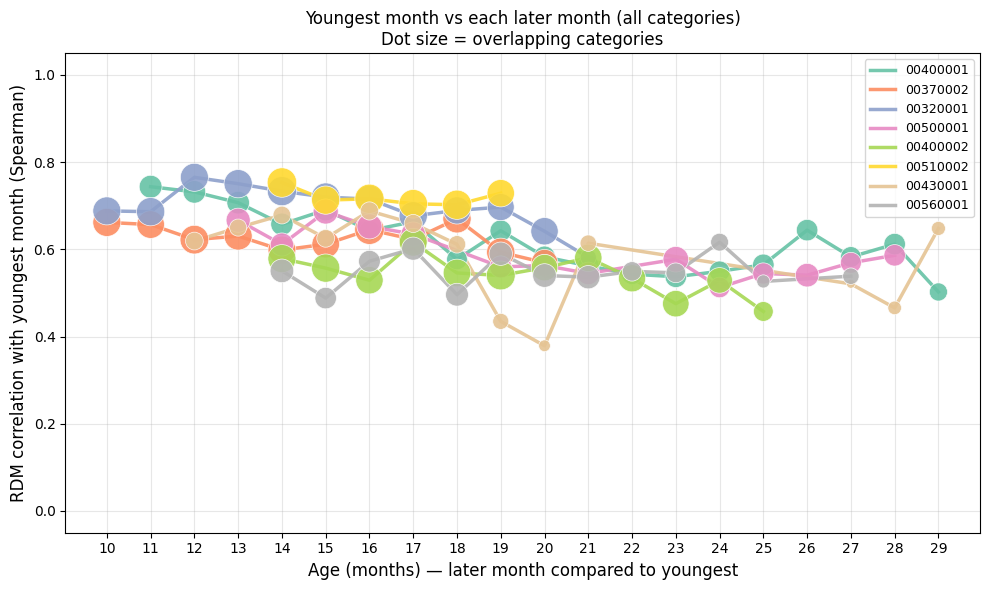

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/youngest_vs_later_top8_densest.png


In [17]:
# Plot: youngest vs each later month (continuous x = age_compared), dot size = n_common
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
n_min_y, n_max_y = trajectory_youngest_df["n_common_categories"].min(), trajectory_youngest_df["n_common_categories"].max()
norm_y = max(n_max_y - n_min_y, 1)
s_min, s_max = 40, 450
for idx, subject_id in enumerate(top8_subject_ids):
    sub = trajectory_youngest_df[trajectory_youngest_df["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    c = colors[idx % len(colors)]
    ax.plot(sub["age_compared"], sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    sizes = s_min + (sub["n_common_categories"] - n_min_y) / norm_y * (s_max - s_min)
    ax.scatter(sub["age_compared"], sub["correlation"], s=sizes, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
age_min = int(trajectory_youngest_df["age_compared"].min())
age_max = int(trajectory_youngest_df["age_compared"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months) — later month compared to youngest", fontsize=12)
ax.set_ylabel("RDM correlation with youngest month (Spearman)", fontsize=12)
ax.set_title("Youngest month vs each later month (all categories)\nDot size = overlapping categories")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'youngest_vs_later_top8_densest.png'}")

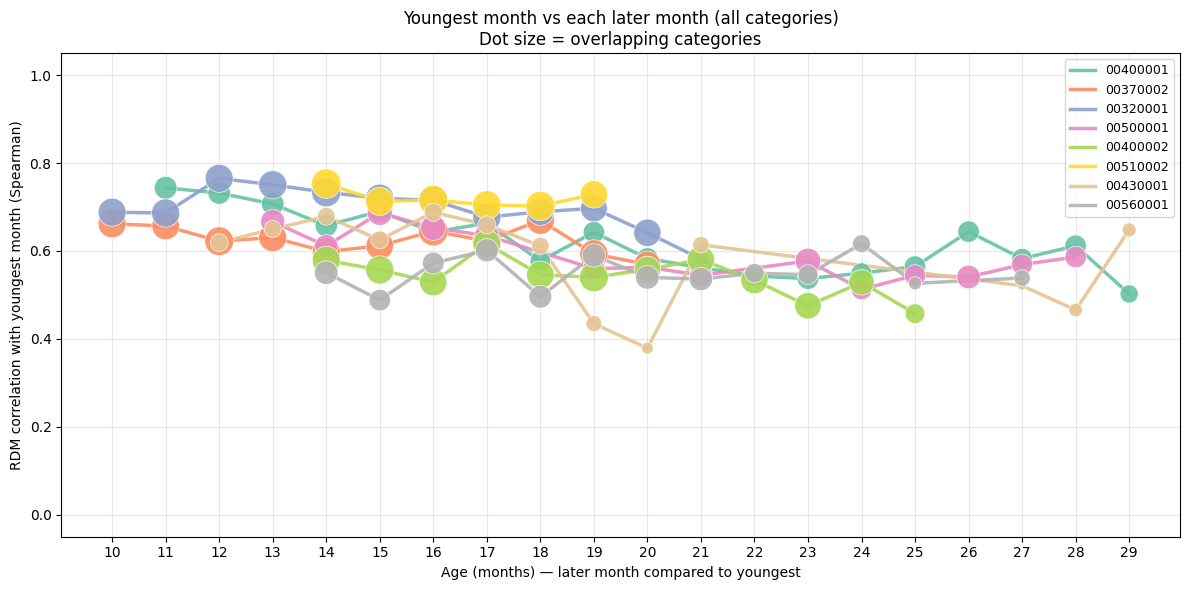

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/youngest_vs_later_top8_densest_categorical.png


In [18]:
# Youngest vs later: categorical x (age_compared as integer ticks)
all_ages_compared = sorted(trajectory_youngest_df["age_compared"].unique())
age_to_xi = {a: i for i, a in enumerate(all_ages_compared)}
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
n_min_y, n_max_y = trajectory_youngest_df["n_common_categories"].min(), trajectory_youngest_df["n_common_categories"].max()
norm_y = max(n_max_y - n_min_y, 1)
s_min, s_max = 40, 450
fig, ax = plt.subplots(figsize=(12, 6))
for idx, subject_id in enumerate(top8_subject_ids):
    sub = trajectory_youngest_df[trajectory_youngest_df["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    x_pos = [age_to_xi[a] for a in sub["age_compared"]]
    c = colors[idx % len(colors)]
    ax.plot(x_pos, sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    sizes = s_min + (sub["n_common_categories"] - n_min_y) / norm_y * (s_max - s_min)
    ax.scatter(x_pos, sub["correlation"], s=sizes, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
ax.set_xticks(range(len(all_ages_compared)))
ax.set_xticklabels([int(a) for a in all_ages_compared])
ax.set_xlabel("Age (months) — later month compared to youngest")
ax.set_ylabel("RDM correlation with youngest month (Spearman)")
ax.set_title("Youngest month vs each later month (all categories)\nDot size = overlapping categories")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'youngest_vs_later_top8_densest_categorical.png'}")

## Plot: correlation trajectory lines per subject

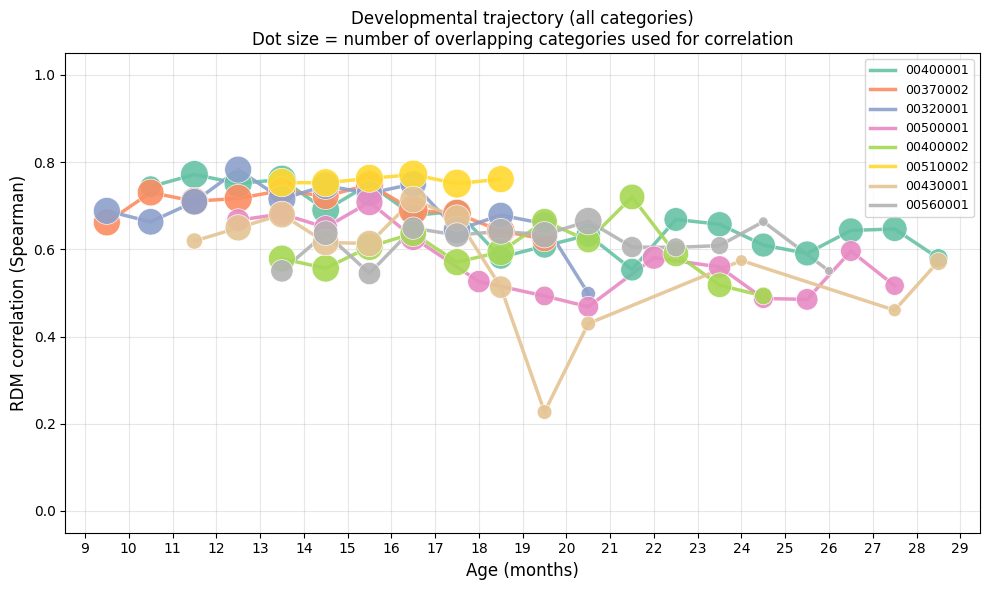

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/correlation_trajectory_top8_densest.png


In [19]:
# One line per subject: x = age (midpoint), y = RDM correlation; dot size = n_common_categories
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
# Map n_common_categories to dot size over a wide range so differences are visible (s in pt²)
n_min, n_max = trajectory_df["n_common_categories"].min(), trajectory_df["n_common_categories"].max()
s_min, s_max = 40, 450  # min and max marker area in points²
norm = max(n_max - n_min, 1)

for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df["subject_id"].values:
        continue
    sub = trajectory_df[trajectory_df["subject_id"] == subject_id].sort_values("age_midpoint")
    c = colors[idx % len(colors)]
    ax.plot(sub["age_midpoint"], sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    sizes = s_min + (sub["n_common_categories"] - n_min) / norm * (s_max - s_min)
    ax.scatter(sub["age_midpoint"], sub["correlation"], s=sizes, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
age_min = int(trajectory_df["age_from"].min())
age_max = int(trajectory_df["age_to"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months)", fontsize=12)
ax.set_ylabel("RDM correlation (Spearman)", fontsize=12)
ax.set_title("Developmental trajectory (all categories)\nDot size = number of overlapping categories used for correlation")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'correlation_trajectory_top8_densest.png'}")

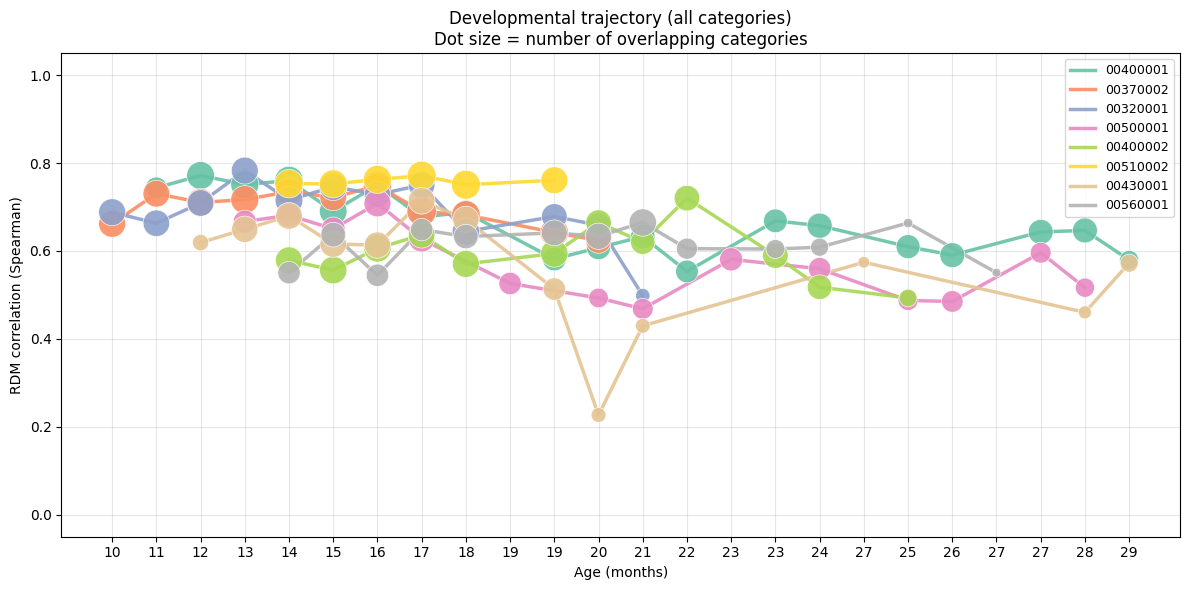

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/correlation_trajectory_top8_densest_categorical.png


In [20]:
# Same with categorical x-axis; dot size = n_common_categories
all_midpoints = sorted(trajectory_df["age_midpoint"].unique())
midpoint_to_xi = {m: i for i, m in enumerate(all_midpoints)}
n_min, n_max = trajectory_df["n_common_categories"].min(), trajectory_df["n_common_categories"].max()
norm = max(n_max - n_min, 1)
s_min, s_max = 40, 450

fig, ax = plt.subplots(figsize=(12, 6))
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df["subject_id"].values:
        continue
    sub = trajectory_df[trajectory_df["subject_id"] == subject_id].sort_values("age_midpoint")
    x_pos = [midpoint_to_xi[m] for m in sub["age_midpoint"]]
    c = colors[idx % len(colors)]
    ax.plot(x_pos, sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    sizes = s_min + (sub["n_common_categories"] - n_min) / norm * (s_max - s_min)
    ax.scatter(x_pos, sub["correlation"], s=sizes, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
labels = [int(trajectory_df[trajectory_df["age_midpoint"] == m].iloc[0]["age_to"]) for m in all_midpoints]
ax.set_xticks(range(len(all_midpoints)))
ax.set_xticklabels(labels)
ax.set_xlabel("Age (months)")
ax.set_ylabel("RDM correlation (Spearman)")
ax.set_title("Developmental trajectory (all categories)\nDot size = number of overlapping categories")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'correlation_trajectory_top8_densest_categorical.png'}")

## Top 50 categories only: same trajectory analysis

Restrict to the **first 50 categories from the long-tailed distribution** (by proportion detected, from `long_tailed_163cats/category_counts_163.csv`). Same set across all subjects. For each subject and each age month we build the RDM using only those 50 categories (with at least `MIN_CATEGORIES_FOR_TOP50` present in that month). Consecutive-month correlations use the common subset of the 50. Dot size is fixed (same 50 categories across age).

In [21]:
# Top 50 categories from long-tailed distribution (first 50 by Count in category_counts_163.csv)
counts_df = pd.read_csv(LONGTAIL_COUNTS_CSV)
ordered_categories_top50 = counts_df["Category"].head(N_TOP_CATEGORIES).tolist()
ordered_categories_top50 = [c for c in ordered_categories_top50 if c in set(ordered_categories)]
subject_month_rdms_top50 = {}
subject_trajectory_top50 = []

for subject_id in tqdm(subject_age_embeddings, desc="Subject (top50)"):
    age_data = subject_age_embeddings[subject_id]
    month_rdms = {}
    for age_mo, cat_embeddings in age_data.items():
        subset = {c: cat_embeddings[c] for c in ordered_categories_top50 if c in cat_embeddings}
        rdm, available = compute_rdm_for_month(
            subset, ordered_categories_top50, MIN_CATEGORIES_FOR_TOP50
        )
        if rdm is not None:
            month_rdms[age_mo] = (rdm, available)
    subject_month_rdms_top50[subject_id] = month_rdms
    ages_sorted = sorted(month_rdms.keys())
    for i in range(len(ages_sorted) - 1):
        a1, a2 = ages_sorted[i], ages_sorted[i + 1]
        rdm1, cats1 = month_rdms[a1]
        rdm2, cats2 = month_rdms[a2]
        corr, n_common = compute_rdm_correlation(rdm1, rdm2, ordered_categories_top50, cats1, cats2)
        subject_trajectory_top50.append({
            "subject_id": subject_id,
            "age_from": a1,
            "age_to": a2,
            "age_midpoint": (a1 + a2) / 2.0,
            "correlation": corr,
            "n_common_categories": n_common,
        })

trajectory_df_top50 = pd.DataFrame(subject_trajectory_top50)
trajectory_df_top50.to_csv(OUTPUT_DIR / "month_to_month_correlations_top50.csv", index=False)
print(f"Top-50 consecutive-month correlations: {len(trajectory_df_top50)} rows")
print(trajectory_df_top50.head(10).to_string())

Subject (top50): 100%|██████████| 8/8 [00:00<00:00, 62.83it/s]

Top-50 consecutive-month correlations: 100 rows
  subject_id  age_from  age_to  age_midpoint  correlation  n_common_categories
0   00400001        10      11          10.5     0.860007                   50
1   00400001        11      12          11.5     0.880763                   50
2   00400001        12      13          12.5     0.914423                   50
3   00400001        13      14          13.5     0.907323                   50
4   00400001        14      15          14.5     0.880490                   50
5   00400001        15      16          15.5     0.874044                   50
6   00400001        16      17          16.5     0.775317                   50
7   00400001        17      18          17.5     0.788448                   50
8   00400001        18      19          18.5     0.739336                   50
9   00400001        19      20          19.5     0.751929                   50


## Youngest month vs each later month (top 50 categories only)

Same as above but using only the first 50 categories. For each subject, correlate the youngest month's RDM with each later month's RDM (top-50 subset). Dot size = overlapping categories.

In [22]:
# Youngest vs each later month, top 50 categories only
subject_trajectory_youngest_top50 = []
for subject_id in subject_month_rdms_top50:
    month_rdms = subject_month_rdms_top50[subject_id]
    if len(month_rdms) < 2:
        continue
    ages_sorted = sorted(month_rdms.keys())
    age_youngest = ages_sorted[0]
    rdm_youngest, cats_youngest = month_rdms[age_youngest]
    for age_other in ages_sorted[1:]:
        rdm_other, cats_other = month_rdms[age_other]
        corr, n_common = compute_rdm_correlation(
            rdm_youngest, rdm_other, ordered_categories_top50, cats_youngest, cats_other
        )
        subject_trajectory_youngest_top50.append({
            "subject_id": subject_id,
            "age_youngest": age_youngest,
            "age_compared": age_other,
            "correlation": corr,
            "n_common_categories": n_common,
        })

trajectory_youngest_df_top50 = pd.DataFrame(subject_trajectory_youngest_top50)
trajectory_youngest_df_top50.to_csv(OUTPUT_DIR / "youngest_vs_later_month_correlations_top50.csv", index=False)
print(f"Youngest vs later (top 50): {len(trajectory_youngest_df_top50)} rows")
print(trajectory_youngest_df_top50.head(12).to_string())

Youngest vs later (top 50): 100 rows
   subject_id  age_youngest  age_compared  correlation  n_common_categories
0    00400001            10            11     0.860007                   50
1    00400001            10            12     0.805743                   50
2    00400001            10            13     0.833326                   50
3    00400001            10            14     0.797761                   50
4    00400001            10            15     0.785874                   50
5    00400001            10            16     0.794428                   50
6    00400001            10            17     0.762590                   50
7    00400001            10            18     0.612264                   50
8    00400001            10            19     0.780890                   50
9    00400001            10            20     0.740914                   50
10   00400001            10            21     0.717873                   50
11   00400001            10            22     0.674

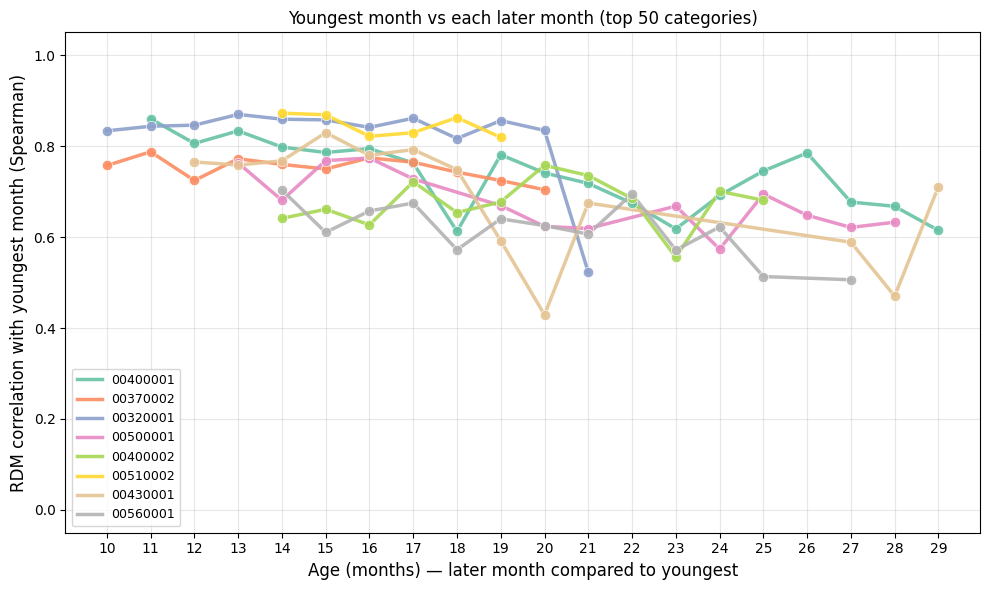

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/youngest_vs_later_top8_densest_top50.png


In [23]:
# Plot: youngest vs later (top 50), continuous x. Fixed dot size (same 50 categories across age).
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
for idx, subject_id in enumerate(top8_subject_ids):
    sub = trajectory_youngest_df_top50[trajectory_youngest_df_top50["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    c = colors[idx % len(colors)]
    ax.plot(sub["age_compared"], sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    ax.scatter(sub["age_compared"], sub["correlation"], s=55, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
age_min = int(trajectory_youngest_df_top50["age_compared"].min())
age_max = int(trajectory_youngest_df_top50["age_compared"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months) — later month compared to youngest", fontsize=12)
ax.set_ylabel("RDM correlation with youngest month (Spearman)", fontsize=12)
ax.set_title("Youngest month vs each later month (top 50 categories)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_top50.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'youngest_vs_later_top8_densest_top50.png'}")

### Stats (top 50 categories): does correlation change with age?

In [24]:
# Same stats for top-50 categories
rho_consec_t50, p_consec_t50 = spearmanr(trajectory_df_top50["age_midpoint"], trajectory_df_top50["correlation"])
rho_young_t50, p_young_t50 = spearmanr(trajectory_youngest_df_top50["age_compared"], trajectory_youngest_df_top50["correlation"])
print("Top 50 categories:")
print("  Consecutive-month Spearman(age_midpoint, correlation): rho = {:.4f}, p = {:.4f}".format(rho_consec_t50, p_consec_t50))
print("  Youngest vs later Spearman(age_compared, correlation): rho = {:.4f}, p = {:.4f}".format(rho_young_t50, p_young_t50))
slopes_young_t50 = []
for sid in trajectory_youngest_df_top50["subject_id"].unique():
    sub = trajectory_youngest_df_top50[trajectory_youngest_df_top50["subject_id"] == sid].sort_values("age_compared")
    if len(sub) < 2:
        continue
    res = linregress(sub["age_compared"], sub["correlation"])
    slopes_young_t50.append(res.slope)
if slopes_young_t50:
    t_young_t50, p_t_young_t50 = ttest_1samp(np.array(slopes_young_t50), 0)
    print("  Within-subject slope (youngest vs later): mean = {:.5f}, t = {:.3f}, p = {:.4f}".format(
        np.mean(slopes_young_t50), t_young_t50, p_t_young_t50))
# Mixed-effects (top 50)
X_young_t50 = sm.add_constant(trajectory_youngest_df_top50[["age_compared"]])
model_young_t50 = MixedLM(trajectory_youngest_df_top50["correlation"], X_young_t50, trajectory_youngest_df_top50["subject_id"]).fit(method="lbfgs")
print("  Mixed-effects (correlation ~ age_compared): age_compared coef = {:.5f}, z = {:.3f}, p = {:.4f}".format(
    model_young_t50.params["age_compared"], model_young_t50.tvalues["age_compared"], model_young_t50.pvalues["age_compared"]))

Top 50 categories:
  Consecutive-month Spearman(age_midpoint, correlation): rho = -0.5680, p = 0.0000
  Youngest vs later Spearman(age_compared, correlation): rho = -0.6124, p = 0.0000
  Within-subject slope (youngest vs later): mean = -0.00824, t = -4.749, p = 0.0021
  Mixed-effects (correlation ~ age_compared): age_compared coef = -0.00945, z = -6.744, p = 0.0000


/data/j7yang/anaconda3/envs/vislearnlabpy/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/data/j7yang/anaconda3/envs/vislearnlabpy/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


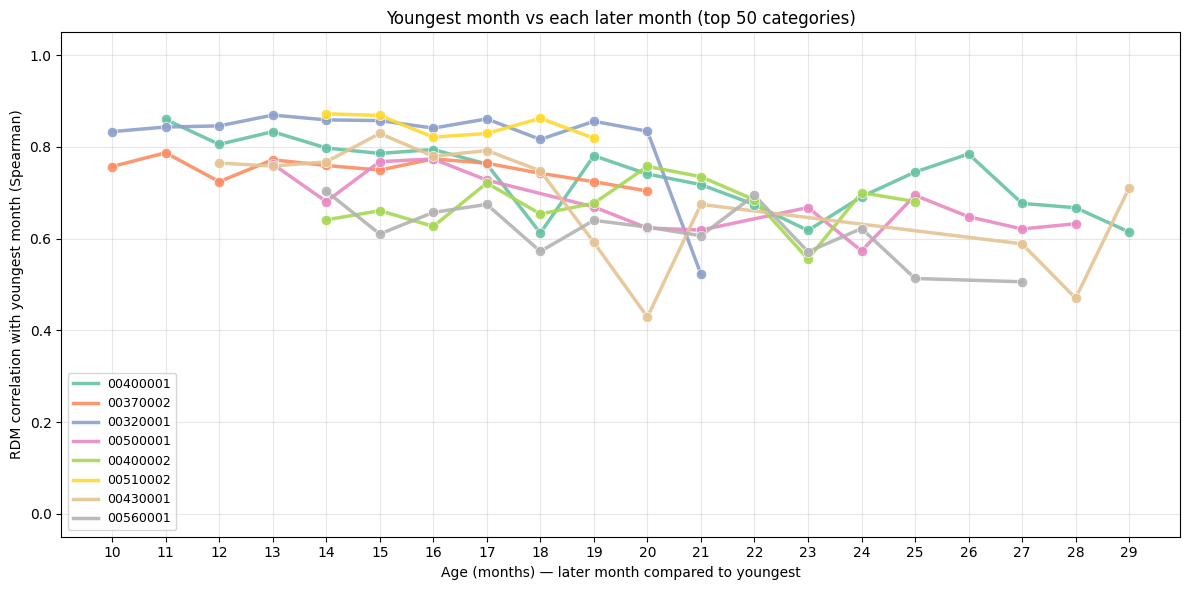

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/youngest_vs_later_top8_densest_top50_categorical.png


In [25]:
# Youngest vs later (top 50): categorical x. Fixed dot size (same 50 categories).
all_ages_compared_t50 = sorted(trajectory_youngest_df_top50["age_compared"].unique())
age_to_xi_t50 = {a: i for i, a in enumerate(all_ages_compared_t50)}
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
fig, ax = plt.subplots(figsize=(12, 6))
for idx, subject_id in enumerate(top8_subject_ids):
    sub = trajectory_youngest_df_top50[trajectory_youngest_df_top50["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    x_pos = [age_to_xi_t50[a] for a in sub["age_compared"]]
    c = colors[idx % len(colors)]
    ax.plot(x_pos, sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    ax.scatter(x_pos, sub["correlation"], s=55, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
ax.set_xticks(range(len(all_ages_compared_t50)))
ax.set_xticklabels([int(a) for a in all_ages_compared_t50])
ax.set_xlabel("Age (months) — later month compared to youngest")
ax.set_ylabel("RDM correlation with youngest month (Spearman)")
ax.set_title("Youngest month vs each later month (top 50 categories)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_top50_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'youngest_vs_later_top8_densest_top50_categorical.png'}")

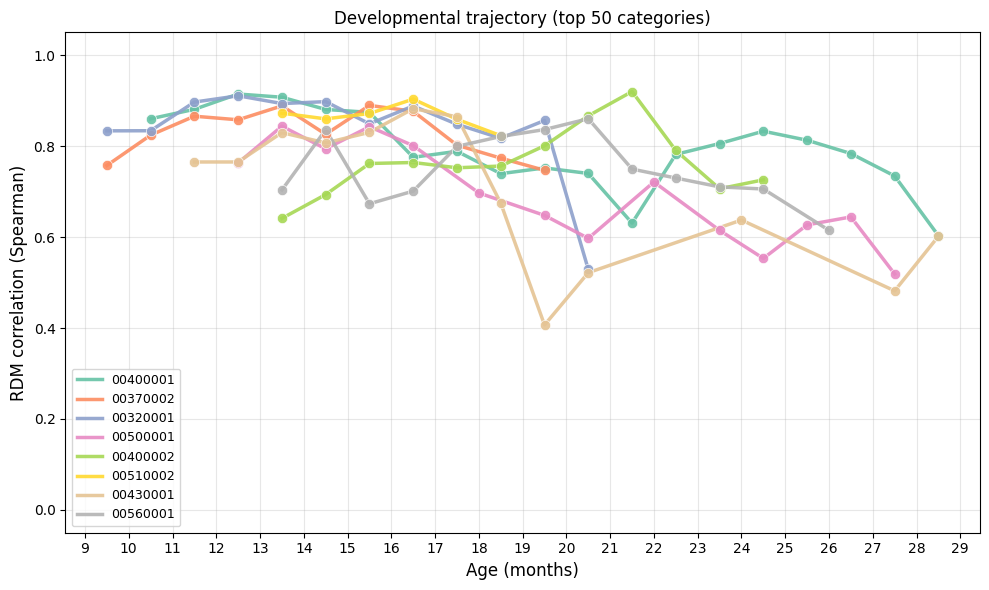

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/correlation_trajectory_top8_densest_top50.png


In [26]:
# Top 50: continuous x-axis. Fixed dot size (same 50 categories across age).
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df_top50["subject_id"].values:
        continue
    sub = trajectory_df_top50[trajectory_df_top50["subject_id"] == subject_id].sort_values("age_midpoint")
    c = colors[idx % len(colors)]
    ax.plot(sub["age_midpoint"], sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    ax.scatter(sub["age_midpoint"], sub["correlation"], s=55, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
age_min = int(trajectory_df_top50["age_from"].min())
age_max = int(trajectory_df_top50["age_to"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months)", fontsize=12)
ax.set_ylabel("RDM correlation (Spearman)", fontsize=12)
ax.set_title("Developmental trajectory (top 50 categories)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_top50.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'correlation_trajectory_top8_densest_top50.png'}")

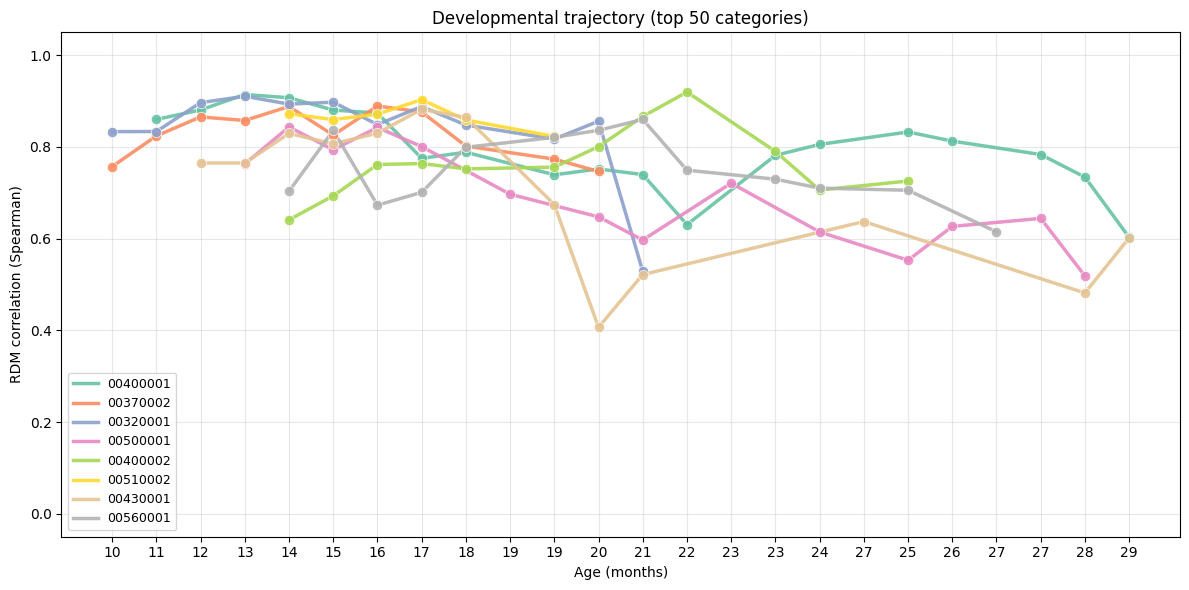

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/correlation_trajectory_top8_densest_top50_categorical.png


In [27]:
# Top 50: categorical x-axis. Fixed dot size (same 50 categories).
all_midpoints_t50 = sorted(trajectory_df_top50["age_midpoint"].unique())
midpoint_to_xi_t50 = {m: i for i, m in enumerate(all_midpoints_t50)}
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
fig, ax = plt.subplots(figsize=(12, 6))
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df_top50["subject_id"].values:
        continue
    sub = trajectory_df_top50[trajectory_df_top50["subject_id"] == subject_id].sort_values("age_midpoint")
    x_pos = [midpoint_to_xi_t50[m] for m in sub["age_midpoint"]]
    c = colors[idx % len(colors)]
    ax.plot(x_pos, sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    ax.scatter(x_pos, sub["correlation"], s=55, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
labels_t50 = [int(trajectory_df_top50[trajectory_df_top50["age_midpoint"] == m].iloc[0]["age_to"]) for m in all_midpoints_t50]
ax.set_xticks(range(len(all_midpoints_t50)))
ax.set_xticklabels(labels_t50)
ax.set_xlabel("Age (months)")
ax.set_ylabel("RDM correlation (Spearman)")
ax.set_title("Developmental trajectory (top 50 categories)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_top50_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'correlation_trajectory_top8_densest_top50_categorical.png'}")